In [2]:
import numpy as np
import pandas as pd

from Bio.Data import CodonTable

In [29]:
heavy_genes = ["ND1", "ND4", "ND4L", "ND5"]

light_genes = [
    "A6", "A8", "CO1", "CO2", "CO3",
    "Cytb", "ND2", "ND3", "ND6"
]

In [12]:
mutspec_ter = pd.read_csv('../data/termite_mutspec12.csv', index_col=0)

mutspec_coc = pd.read_csv('../data/cocroach_mutspec12.csv', index_col=0)

In [11]:
mutspec_ter

,Species,Mut,ExpNum,MutSpec,ObsNum
199,Anacanthotermes_ochraceus,A>C,11.74520,0.081589,1.958796
198,Anacanthotermes_ochraceus,A>G,40.69540,0.021584,1.795407
197,Anacanthotermes_ochraceus,A>T,11.74520,0.237921,5.711995
200,Anacanthotermes_ochraceus,C>A,5.71205,0.084014,0.980930
201,Anacanthotermes_ochraceus,C>G,5.71205,0.000000,0.000000
...,...,...,...,...,...
310,Trinervitermes_geminatus,G>C,14.67210,0.000000,0.000000
304,Trinervitermes_geminatus,G>T,14.67210,0.000000,0.000000
306,Trinervitermes_geminatus,T>A,100.49100,0.011822,0.322340
300,Trinervitermes_geminatus,T>C,139.53800,0.100865,3.818814


In [26]:
blat_aa = pd.read_csv('../data/midori_Blattodea_aa_fracs.tsv', sep='\t')

In [28]:
blat_aa

,Species_name,Organism,Gene_name,Phe_frac,Leu_frac,Leu2_frac,Ser_frac,Pro_frac,Cys_frac,Trp_frac,...,Ser2_frac,Asp_frac,Glu_frac,Asn_frac,Lys_frac,Val_frac,Ile_frac,Met_frac,Ala_frac,Thr_frac
0,Acanthotermes_acanthothorax_187525,Termites,A6,0.052863,0.017621,0.004405,0.088106,0.008811,0.083700,0.066079,...,0.008811,0.088106,0.061674,0.017621,0.030837,0.101322,0.008811,0.013216,0.022026,0.004405
1,Acanthotermes_acanthothorax_187525,Termites,A8,0.094340,0.056604,0.037736,0.056604,0.000000,0.094340,0.018868,...,0.037736,0.037736,0.075472,0.018868,0.018868,0.113208,0.056604,0.000000,0.018868,0.000000
2,Acanthotermes_acanthothorax_187525,Termites,CO1,0.029183,0.017510,0.007782,0.145914,0.003891,0.089494,0.068093,...,0.023346,0.048638,0.075875,0.036965,0.033074,0.105058,0.011673,0.009728,0.009728,0.007782
3,Acanthotermes_acanthothorax_187525,Termites,CO2,0.047619,0.051948,0.012987,0.090909,0.008658,0.082251,0.073593,...,0.012987,0.056277,0.043290,0.043290,0.004329,0.121212,0.021645,0.017316,0.034632,0.008658
4,Acanthotermes_acanthothorax_187525,Termites,CO3,0.045627,0.034221,0.003802,0.136882,0.007605,0.121673,0.068441,...,0.019011,0.049430,0.079848,0.034221,0.026616,0.106464,0.011407,0.015209,0.011407,0.011407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5156,Zootermopsis_nevadensis_136037,Termites,ND3,0.076271,0.016949,0.016949,0.093220,0.016949,0.127119,0.059322,...,0.008475,0.067797,0.033898,0.050847,0.050847,0.050847,0.008475,0.008475,0.008475,0.000000
5157,Zootermopsis_nevadensis_136037,Termites,ND4,0.006726,0.002242,0.026906,0.022422,0.047085,0.004484,0.015695,...,0.123318,0.008969,0.006726,0.121076,0.141256,0.004484,0.040359,0.060538,0.002242,0.130045
5158,Zootermopsis_nevadensis_136037,Termites,ND4L,0.000000,0.020833,0.041667,0.010417,0.031250,0.000000,0.010417,...,0.072917,0.000000,0.000000,0.125000,0.177083,0.000000,0.041667,0.104167,0.000000,0.135417
5159,Zootermopsis_nevadensis_136037,Termites,ND5,0.006957,0.005217,0.027826,0.027826,0.038261,0.001739,0.005217,...,0.146087,0.001739,0.008696,0.137391,0.165217,0.001739,0.059130,0.055652,0.003478,0.104348


In [30]:
sorted(blat_aa["Gene_name"].dropna().unique())

['A6',
 'A8',
 'CO1',
 'CO2',
 'CO3',
 'Cytb',
 'ND1',
 'ND2',
 'ND3',
 'ND4',
 'ND4L',
 'ND5',
 'ND6']

In [55]:
aa_column_mapping = {
    "Phe_frac": "F",
    "Leu_frac": "L",
    "Leu2_frac": "L",
    "Ile_frac": "I",
    "Met_frac": "M",
    "Val_frac": "V",
    "Ser_frac": "S",
    "Ser2_frac": "S",
    "Pro_frac": "P",
    "Thr_frac": "T",
    "Ala_frac": "A",
    "Tyr_frac": "Y",
    "His_frac": "H",
    "Gln_frac": "Q",
    "Asn_frac": "N",
    "Lys_frac": "K",
    "Asp_frac": "D",
    "Glu_frac": "E",
    "Cys_frac": "C",
    "Trp_frac": "W",
    "Arg_frac": "R",
    "Gly_frac": "G"
}

In [56]:
def prepare_amino_acid_table(df):
    metadata_cols = [
        col
        for col in ["Species_name", "Organism", "Gene_name"]
        if col in df.columns
    ]

    result = df[metadata_cols].copy()

    available_mapping = {
        col: aa
        for col, aa in aa_column_mapping.items()
        if col in df.columns
    }

    for aa in sorted(set(available_mapping.values())):
        source_cols = [
            col
            for col, mapped_aa in available_mapping.items()
            if mapped_aa == aa
        ]

        result[aa] = df[source_cols].sum(
            axis=1,
            min_count=1
        )

    return result

In [57]:
aa_clean = prepare_amino_acid_table(blat_aa)

In [58]:
aa_cols = [
    col
    for col in aa_clean.columns
    if col in set("ACDEFGHIKLMNPQRSTVWY")
]

aa_clean[aa_cols].sum(axis=1).describe()

count    5161.000000
mean        0.912285
std         0.034124
min         0.814159
25%         0.892442
50%         0.910145
75%         0.937500
max         1.000000
dtype: float64

In [59]:
def calculate_observed_aa_difference(
    aa_df,
    genes,
    species_col="Species_name",
    group_col="Organism",
    gene_col="Gene_name"
):
    data = aa_df[
        aa_df[gene_col].isin(genes)
    ].copy()

    aa_cols = [
        col
        for col in data.columns
        if col in set("ACDEFGHIKLMNPQRSTVWY")
    ]

    # Каждый вид получает один усреднённый профиль
    species_means = (
        data
        .groupby(
            [species_col, group_col],
            as_index=False
        )[aa_cols]
        .mean()
    )

    group_means = (
        species_means
        .groupby(group_col)[aa_cols]
        .mean()
    )

    required_groups = {"Termites", "Cockroaches"}

    if not required_groups.issubset(group_means.index):
        raise ValueError(
            f"В {group_col} должны быть группы "
            f"'Termites' и 'Cockroaches'. "
            f"Найдены: {group_means.index.tolist()}"
        )

    result = pd.DataFrame({
        "amino_acid": aa_cols,
        "mean_termites": group_means.loc[
            "Termites", aa_cols
        ].values,
        "mean_cockroaches": group_means.loc[
            "Cockroaches", aa_cols
        ].values
    })

    result["observed_delta"] = (
        result["mean_termites"]
        - result["mean_cockroaches"]
    )

    return result, species_means

In [60]:
observed_light, species_light = (
    calculate_observed_aa_difference(
        aa_clean,
        light_genes
    )
)

observed_heavy, species_heavy = (
    calculate_observed_aa_difference(
        aa_clean,
        heavy_genes
    )
)

In [61]:
def prepare_group_mutation_spectrum(
    mutspec_df,
    group_name,
    species_col="Species",
    mutation_col="Mut",
    value_col="MutSpec"
):
    data = mutspec_df[
        [species_col, mutation_col, value_col]
    ].copy()

    data[value_col] = pd.to_numeric(
        data[value_col],
        errors="coerce"
    )

    data = data.dropna(
        subset=[species_col, mutation_col, value_col]
    )

    species_spectrum = (
        data
        .groupby(
            [species_col, mutation_col],
            as_index=False
        )[value_col]
        .mean()
    )

    species_spectrum["spectrum_sum"] = (
        species_spectrum
        .groupby(species_col)[value_col]
        .transform("sum")
    )

    species_spectrum["normalized_mutspec"] = np.where(
        species_spectrum["spectrum_sum"] > 0,
        species_spectrum[value_col]
        / species_spectrum["spectrum_sum"],
        np.nan
    )

    species_spectrum = species_spectrum.dropna(
        subset=["normalized_mutspec"]
    )

    group_spectrum = (
        species_spectrum
        .groupby(
            mutation_col,
            as_index=False
        )["normalized_mutspec"]
        .mean()
        .rename(
            columns={
                "normalized_mutspec": group_name
            }
        )
    )

    return group_spectrum

In [62]:
termite_spectrum = prepare_group_mutation_spectrum(
    mutspec_ter,
    group_name="Termites"
)

cockroach_spectrum = prepare_group_mutation_spectrum(
    mutspec_coc,
    group_name="Cockroaches"
)

In [63]:
spectrum_comparison = termite_spectrum.merge(
    cockroach_spectrum,
    on="Mut",
    how="outer"
).fillna(0)

In [64]:
spectrum_comparison["spectrum_delta"] = (
    spectrum_comparison["Termites"]
    - spectrum_comparison["Cockroaches"]
)

In [65]:
spectrum_comparison.sort_values(
    "spectrum_delta",
    ascending=False
)

,Mut,Termites,Cockroaches,spectrum_delta
1,A>G,0.146283,0.078139,0.068144
8,G>T,0.086381,0.030289,0.056093
7,G>C,0.039648,0.008766,0.030882
2,A>T,0.056654,0.035899,0.020756
0,A>C,0.022015,0.007043,0.014971
10,T>C,0.061486,0.060293,0.001193
11,T>G,0.008474,0.014350,-0.005876
5,C>T,0.382656,0.394334,-0.011678
9,T>A,0.016462,0.030300,-0.013838
4,C>G,0.001509,0.017348,-0.015839


In [66]:
light_spectrum_delta = spectrum_comparison[
    ["Mut", "spectrum_delta"]
].copy()

In [67]:
COMPLEMENT = {
    "A": "T",
    "T": "A",
    "C": "G",
    "G": "C"
}

In [68]:
def complement_mutation(mutation):
    source, target = mutation.split(">")

    return (
        f"{COMPLEMENT[source]}"
        f">{COMPLEMENT[target]}"
    )

In [69]:
def complement_spectrum(spectrum_df):
    result = spectrum_df[
        ["Mut", "spectrum_delta"]
    ].copy()

    result["Mut"] = result["Mut"].apply(
        complement_mutation
    )

    result = (
        result
        .groupby(
            "Mut",
            as_index=False
        )["spectrum_delta"]
        .sum()
    )

    return result

In [70]:
heavy_spectrum_delta = complement_spectrum(
    light_spectrum_delta
)

In [71]:
light_spectrum_delta.merge(
    heavy_spectrum_delta,
    on="Mut",
    how="outer",
    suffixes=("_light", "_heavy")
).fillna(0)

,Mut,spectrum_delta_light,spectrum_delta_heavy
0,A>C,0.014971,-0.005876
1,A>G,0.068144,0.001193
2,A>T,0.020756,-0.013838
3,C>A,-0.049398,0.056093
4,C>G,-0.015839,0.030882
5,C>T,-0.011678,-0.095410
6,G>A,-0.095410,-0.011678
7,G>C,0.030882,-0.015839
8,G>T,0.056093,-0.049398
9,T>A,-0.013838,0.020756


In [72]:
def mutation_spectrum_to_aa_direction(
    spectrum_delta_df,
    genetic_code=5
):
    table = CodonTable.unambiguous_dna_by_id[
        genetic_code
    ]

    codon_to_aa = table.forward_table
    codons = sorted(codon_to_aa.keys())

    spectrum_delta = dict(
        zip(
            spectrum_delta_df["Mut"],
            spectrum_delta_df["spectrum_delta"]
        )
    )

    amino_acids = sorted(
        set(codon_to_aa.values())
    )

    aa_effect = {
        aa: 0.0
        for aa in amino_acids
    }

    transition_rows = []

    # Пока все исходные кодоны считаем равновероятными
    codon_weight = 1 / len(codons)

    for source_codon in codons:
        source_aa = codon_to_aa[source_codon]

        for position in range(3):
            old_base = source_codon[position]

            for new_base in "ATGC":
                if new_base == old_base:
                    continue

                mutation = f"{old_base}>{new_base}"

                mutation_delta = spectrum_delta.get(
                    mutation,
                    0.0
                )

                if mutation_delta == 0:
                    continue

                target_codon = (
                    source_codon[:position]
                    + new_base
                    + source_codon[position + 1:]
                )

                # Стоп-кодоны исключаем
                if target_codon not in codon_to_aa:
                    continue

                target_aa = codon_to_aa[target_codon]

                # Синонимичная замена AA не меняет
                if target_aa == source_aa:
                    continue

                contribution = (
                    codon_weight
                    * mutation_delta
                )

                aa_effect[source_aa] -= contribution
                aa_effect[target_aa] += contribution

                transition_rows.append({
                    "source_codon": source_codon,
                    "target_codon": target_codon,
                    "position": position + 1,
                    "mutation": mutation,
                    "source_aa": source_aa,
                    "target_aa": target_aa,
                    "spectrum_delta": mutation_delta,
                    "contribution": contribution
                })

    predicted = pd.DataFrame({
        "amino_acid": list(aa_effect.keys()),
        "predicted_delta": list(aa_effect.values())
    })

    transitions = pd.DataFrame(
        transition_rows
    )

    return predicted, transitions

In [73]:
predicted_light, transitions_light = (
    mutation_spectrum_to_aa_direction(
        light_spectrum_delta,
        genetic_code=5
    )
)

In [74]:
predicted_heavy, transitions_heavy = (
    mutation_spectrum_to_aa_direction(
        heavy_spectrum_delta,
        genetic_code=5
    )
)

In [85]:
def compare_observed_and_predicted(
    observed_df,
    predicted_df,
    tolerance=1e-12
):
    comparison = observed_df.merge(
        predicted_df,
        on="amino_acid",
        how="inner"
    )

    comparison["observed_direction"] = np.select(
        [
            comparison["observed_delta"] > tolerance,
            comparison["observed_delta"] < -tolerance
        ],
        [
            "increase",
            "decrease"
        ],
        default="no_change"
    )

    comparison["predicted_direction"] = np.select(
        [
            comparison["predicted_delta"] > tolerance,
            comparison["predicted_delta"] < -tolerance
        ],
        [
            "increase",
            "decrease"
        ],
        default="no_prediction"
    )

    comparison["informative"] = (
        comparison["predicted_direction"] != "no_prediction"
    )

    comparison["direction_match"] = (
        comparison["informative"]
        & (
            comparison["observed_direction"]
            == comparison["predicted_direction"]
        )
    )

    informative = comparison[
        comparison["informative"]
    ].copy()

    if len(informative) > 0:
        match_percent = (
            informative["direction_match"].mean() * 100
        )
    else:
        match_percent = np.nan

    return comparison, match_percent

In [86]:
comparison_light, match_percent_light = (
    compare_observed_and_predicted(
        observed_light,
        predicted_light
    )
)

comparison_heavy, match_percent_heavy = (
    compare_observed_and_predicted(
        observed_heavy,
        predicted_heavy
    )
)

In [87]:
print(
    "Light genes direction match:",
    f"{match_percent_light:.1f}%"
)

print(
    "Heavy genes direction match:",
    f"{match_percent_heavy:.1f}%"
)

Light genes direction match: 65.0%
Heavy genes direction match: 85.0%


In [88]:
aa_names = {
    "A": "Ala",
    "R": "Arg",
    "N": "Asn",
    "D": "Asp",
    "C": "Cys",
    "Q": "Gln",
    "E": "Glu",
    "G": "Gly",
    "H": "His",
    "I": "Ile",
    "L": "Leu",
    "K": "Lys",
    "M": "Met",
    "F": "Phe",
    "P": "Pro",
    "S": "Ser",
    "T": "Thr",
    "W": "Trp",
    "Y": "Tyr",
    "V": "Val"
}

In [89]:
def show_predicted_amino_acid_changes(
    predicted_df,
    tolerance=1e-12
):
    result = predicted_df.copy()

    result["amino_acid_name"] = (
        result["amino_acid"].map(aa_names)
    )

    result["predicted_direction"] = np.select(
        [
            result["predicted_delta"] > tolerance,
            result["predicted_delta"] < -tolerance
        ],
        [
            "increase",
            "decrease"
        ],
        default="no_change"
    )

    result["absolute_predicted_effect"] = (
        result["predicted_delta"].abs()
    )

    return result.sort_values(
        "absolute_predicted_effect",
        ascending=False
    )

In [90]:
predicted_changes_light = (
    show_predicted_amino_acid_changes(
        predicted_light
    )
)

predicted_changes_heavy = (
    show_predicted_amino_acid_changes(
        predicted_heavy
    )
)

In [91]:
predicted_changes_light[
    [
        "amino_acid",
        "amino_acid_name",
        "predicted_delta",
        "predicted_direction"
    ]
]

,amino_acid,amino_acid_name,predicted_delta,predicted_direction
8,K,Lys,-0.019170,decrease
12,P,Pro,0.015995,increase
9,L,Leu,0.014331,increase
11,N,Asn,-0.013587,decrease
0,A,Ala,0.011537,increase
14,R,Arg,0.011537,increase
10,M,Met,-0.009118,decrease
16,T,Thr,-0.008939,decrease
17,V,Val,0.008939,increase
4,F,Phe,0.008749,increase


In [92]:
predicted_changes_heavy[
    [
        "amino_acid",
        "amino_acid_name",
        "predicted_delta",
        "predicted_direction"
    ]
]

,amino_acid,amino_acid_name,predicted_delta,predicted_direction
9,L,Leu,-0.025868,decrease
4,F,Phe,-0.020286,decrease
5,G,Gly,0.015995,increase
0,A,Ala,0.011537,increase
14,R,Arg,0.011537,increase
7,I,Ile,-0.009118,decrease
17,V,Val,-0.008939,decrease
16,T,Thr,0.008939,increase
3,E,Glu,0.007971,increase
1,C,Cys,-0.007819,decrease


In [93]:
light_increased = predicted_changes_light[
    predicted_changes_light["predicted_direction"] == "increase"
][
    [
        "amino_acid",
        "amino_acid_name",
        "predicted_delta"
    ]
]

light_increased

,amino_acid,amino_acid_name,predicted_delta
12,P,Pro,0.015995
9,L,Leu,0.014331
0,A,Ala,0.011537
14,R,Arg,0.011537
17,V,Val,0.008939
4,F,Phe,0.008749
1,C,Cys,0.007819
5,G,Gly,0.007079


In [94]:
heavy_increased = predicted_changes_heavy[
    predicted_changes_heavy["predicted_direction"] == "increase"
][
    [
        "amino_acid",
        "amino_acid_name",
        "predicted_delta"
    ]
]

heavy_increased

,amino_acid,amino_acid_name,predicted_delta
5,G,Gly,0.015995
0,A,Ala,0.011537
14,R,Arg,0.011537
16,T,Thr,0.008939
3,E,Glu,0.007971
8,K,Lys,0.007633
12,P,Pro,0.007079
2,D,Asp,0.003349
13,Q,Gln,0.002543
11,N,Asn,0.002050


In [95]:
light_decreased = predicted_changes_light[
    predicted_changes_light["predicted_direction"] == "decrease"
][
    [
        "amino_acid",
        "amino_acid_name",
        "predicted_delta"
    ]
]

light_decreased

,amino_acid,amino_acid_name,predicted_delta
8,K,Lys,-0.019170
11,N,Asn,-0.013587
10,M,Met,-0.009118
16,T,Thr,-0.008939
13,Q,Gln,-0.008234
3,E,Glu,-0.008049
19,Y,Tyr,-0.005769
18,W,Trp,-0.004156
2,D,Asp,-0.003349
7,I,Ile,-0.002419


In [96]:
heavy_decreased = predicted_changes_heavy[
    predicted_changes_heavy["predicted_direction"] == "decrease"
][
    [
        "amino_acid",
        "amino_acid_name",
        "predicted_delta"
    ]
]

heavy_decreased

,amino_acid,amino_acid_name,predicted_delta
9,L,Leu,-0.025868
4,F,Phe,-0.020286
7,I,Ile,-0.009118
17,V,Val,-0.008939
1,C,Cys,-0.007819
19,Y,Tyr,-0.005769
10,M,Met,-0.002419
18,W,Trp,-0.001535


In [97]:
print(
    "Light genes — predicted increase:",
    ", ".join(light_increased["amino_acid_name"])
)

print(
    "Light genes — predicted decrease:",
    ", ".join(light_decreased["amino_acid_name"])
)

print(
    "Heavy genes — predicted increase:",
    ", ".join(heavy_increased["amino_acid_name"])
)

print(
    "Heavy genes — predicted decrease:",
    ", ".join(heavy_decreased["amino_acid_name"])
)

Light genes — predicted increase: Pro, Leu, Ala, Arg, Val, Phe, Cys, Gly
Light genes — predicted decrease: Lys, Asn, Met, Thr, Gln, Glu, Tyr, Trp, Asp, Ile, Ser, His
Heavy genes — predicted increase: Gly, Ala, Arg, Thr, Glu, Lys, Pro, Asp, Gln, Asn, Ser, His
Heavy genes — predicted decrease: Leu, Phe, Ile, Val, Cys, Tyr, Met, Trp


In [98]:
def make_aa_change_summary(comparison_df):
    result = comparison_df.copy()

    result["amino_acid_name"] = (
        result["amino_acid"].map(aa_names)
    )

    result["observed_change"] = np.where(
        result["observed_delta"] > 0,
        "increase",
        np.where(
            result["observed_delta"] < 0,
            "decrease",
            "no_change"
        )
    )

    result["mutation_predicted_change"] = np.where(
        result["predicted_delta"] > 0,
        "increase",
        np.where(
            result["predicted_delta"] < 0,
            "decrease",
            "no_change"
        )
    )

    return result[
        [
            "amino_acid",
            "amino_acid_name",
            "mean_termites",
            "mean_cockroaches",
            "observed_delta",
            "observed_change",
            "predicted_delta",
            "mutation_predicted_change",
            "direction_match"
        ]
    ].sort_values(
        "predicted_delta",
        ascending=False
    )

In [99]:
light_aa_summary = make_aa_change_summary(
    comparison_light
)

heavy_aa_summary = make_aa_change_summary(
    comparison_heavy
)

In [100]:
light_aa_summary

,amino_acid,amino_acid_name,mean_termites,mean_cockroaches,observed_delta,observed_change,predicted_delta,mutation_predicted_change,direction_match
12,P,Pro,0.010794,0.005207,0.005587,increase,0.015995,increase,True
9,L,Leu,0.040759,0.033072,0.007687,increase,0.014331,increase,True
0,A,Ala,0.010713,0.004732,0.005981,increase,0.011537,increase,True
14,R,Arg,0.009280,0.002696,0.006584,increase,0.011537,increase,True
17,V,Val,0.080328,0.029593,0.050734,increase,0.008939,increase,True
4,F,Phe,0.055509,0.057065,-0.001556,decrease,0.008749,increase,False
1,C,Cys,0.095237,0.066529,0.028709,increase,0.007819,increase,True
5,G,Gly,0.044324,0.026749,0.017576,increase,0.007079,increase,True
6,H,His,0.011816,0.005604,0.006212,increase,-0.001120,decrease,False
15,S,Ser,0.125861,0.145462,-0.019601,decrease,-0.002076,decrease,True


In [104]:
light_aa_summary['direction_match'].sum()

13

In [101]:
heavy_aa_summary

,amino_acid,amino_acid_name,mean_termites,mean_cockroaches,observed_delta,observed_change,predicted_delta,mutation_predicted_change,direction_match
5,G,Gly,0.013141,0.005756,0.007385,increase,0.015995,increase,True
0,A,Ala,0.012821,0.003610,0.009211,increase,0.011537,increase,True
14,R,Arg,0.008943,0.003410,0.005533,increase,0.011537,increase,True
16,T,Thr,0.103350,0.083096,0.020253,increase,0.008939,increase,True
3,E,Glu,0.011860,0.005177,0.006683,increase,0.007971,increase,True
8,K,Lys,0.149985,0.132691,0.017294,increase,0.007633,increase,True
12,P,Pro,0.040634,0.018457,0.022177,increase,0.007079,increase,True
2,D,Asp,0.007497,0.004695,0.002802,increase,0.003349,increase,True
13,Q,Gln,0.088722,0.037854,0.050868,increase,0.002543,increase,True
11,N,Asn,0.127386,0.117365,0.010021,increase,0.002050,increase,True


In [105]:
heavy_aa_summary['direction_match'].sum()

17

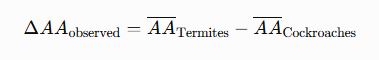

По мутспеку - в начале считалось среднее значение каждой замены для термитов и тараканов отдельно. Затем для каждого типа мутаций рассчитывалась разница

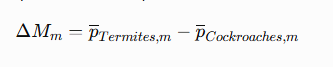

Как считался predicted - Берём исходный кодон, Перебираем каждую позицию, учитываем все возможные несинонимичные замены. Для каждого несинонимичного перехода рассчитывался вклад

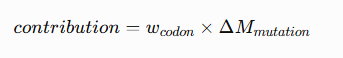

В текущей версии все кодоны считались равновероятными

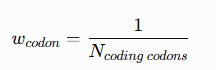

Например, если:

ΔM(A>G)=0.08

и вес кодона:

w (AAA)=0.016

то для перехода:

AAA → GAA
Lys → Glu

вклад будет:

0.016×0.08=0.00128

Этот вклад:

вычитается из Lys;
добавляется к Glu.
aa_effect["K"] -= contribution
aa_effect["E"] += contribution

Для каждой аминокислоты суммировались:

все входящие мутационные переходы;
все исходящие мутационные переходы.

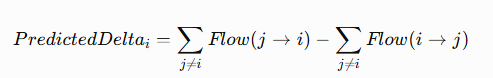

Для каждой однонуклеотидной замены мы определяли, приводит ли она к изменению кодируемой аминокислоты в соответствии с митохондриальным генетическим кодом беспозвоночных. Вклад каждого несинонимичного перехода взвешивался на разницу частоты соответствующего типа мутации между термитами и тараканами. Для каждой аминокислоты рассчитывался суммарный баланс входящих и исходящих мутационных переходов. Положительный баланс интерпретировался как ожидаемое увеличение аминокислоты у термитов, отрицательный — как ожидаемое уменьшение. Поскольку мутационный спектр был рассчитан по light-strand гену CO1, для light-генов он использовался в исходной ориентации, а для heavy-генов мутации были преобразованы в комплементарную ориентацию.